Improve fitting of tuning curves!
- try mixture of gaussians!
- also implement linear shift for significance (instead of bootstrap)

#TODO:
- make mat_by_cond and tuning generating functions switch flexibly between median and mean
- rewrite and rerun plotting gaussian function to use median across trials
- linear shift gaussian fitting tuning


In [1]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

#JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
# 
experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip4_10may, JAL8_14may]

In [192]:
%load_ext autoreload
from JR_test_scripts.escape.escape_utils import load, load_homing
from behave_analysis.utils.creating_directories import make_directory
from JR_test_scripts.escape.escape_data_loading_funcs import extract_homing_and_escape_periods
from JR_test_scripts.escape.escape_tuning_funcs import neuron_tuning_by_var, single_trial_tuning, fit_gaussian, fit_double_gaussian, gaussian_fitting
from JR_test_scripts.escape.escape_plotting_funcs import plot_gaussian_fit_tuning
from behave_analysis.utils.creating_directories import make_directory
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [272]:
"""Make plots for the neurons using their gaussian fitted tuning curves for sorting. Compare across conditions!
Plot only neurons with xval tuning curves"""

%autoreload 2
# compression_var = ['y_pos', 'distance_shelter', 'escape', 'speed'] 
# [['full_distance_shelter','distance_shelter','distance_first_goal'],['escape', 'escape_shelter', 'escape_first_goal']]
# compression_var = ['bird_dist_shelter','bird_dist_first_goal']
compression_var = ['escape']

for i, exp in enumerate(experiments_objects[7:8]):
    # load data
    # session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, escape, outofshelter = load(exp)
    # ons, offs, homie = load_homing(session, len(behave))
    for comp in compression_var:
        
        nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
        dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/"+nickname)
        var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, comp, ons, offs, no_stationary = False, return_escape = True)
        
        # compute xval tuning during homing/escape
        peak_firing_condition, tuning, xval = neuron_tuning_by_var(var, escape_matrix, cond, h_start)
        mat_by_cond = single_trial_tuning(escape_matrix, var, cond, h_start, averaging = 'mean')
        y_fitted_all, R_all, param_all, shift_constant_all, double_wins_all = plot_gaussian_fit_tuning(tuning, xval, dump_path, mat_by_cond, comp, xval_true = True, verbose = False)


In [ ]:
"""Fitting a GMM using 'sample weights' 
#TODO this is buggy because sample weights is not a correct argument"""

import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Example firing rate data
firing_rates = tuning[0][17,:]
distances = np.arange(len(firing_rates))

# Fit GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(np.expand_dims(distances, axis=1), sample_weight=firing_rates)

# Extract GMM parameters
means = gmm.means_.flatten()  # Centers of the Gaussians
weights = gmm.weights_        # Weights of each component
std_devs = np.sqrt(gmm.covariances_.flatten())  # Standard deviations

# Plot results
plt.plot(distances, firing_rates, label="Firing Rates")
for mean, weight, std in zip(means, weights, std_devs):
    gaussian = weight * np.exp(-((distances - mean) ** 2) / (2 * std**2))
    plt.plot(distances, gaussian, '--', label=f"Component at {mean:.1f}")
plt.legend()
plt.title("GMM Fit to Tuning Curve")
plt.xlabel("Distance")
plt.ylabel("Firing Rate")
plt.show()

TypeError: BaseMixture.fit() got an unexpected keyword argument 'sample_weight'

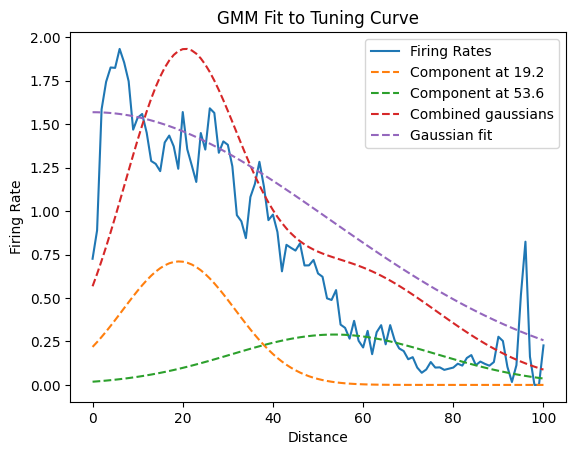

In [8]:
"""Fitting a GMM but without using 'sample weights' as an input because of version compatibility issues"""

condition = 0
neuron = 17

# Example firing rate data
firing_rates = tuning[condition][neuron,:]
firing_rates += np.abs(np.amin(firing_rates))
distances = np.arange(len(firing_rates))

# Repeat distances based on their firing rates
repeat_factor = 100  # Adjust to control the density of points
weighted_distances = np.repeat(distances, (firing_rates * repeat_factor).astype(int))

# Fit GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(weighted_distances.reshape(-1, 1))

# Extract GMM parameters
means = gmm.means_.flatten()  # Centers of the Gaussians
weights = gmm.weights_        # Weights of each component
std_devs = np.sqrt(gmm.covariances_.flatten())  # Standard deviations

# Plot results
plt.plot(distances, firing_rates, label="Firing Rates")
predicted_curve  = np.zeros_like(firing_rates)
for mean, weight, std in zip(means, weights, std_devs):
    gaussian = weight * np.exp(-((distances - mean) ** 2) / (2 * std**2))
    predicted_curve  += gaussian
    plt.plot(distances, gaussian, '--', label=f"Component at {mean:.1f}")

# Rescale the predicted curve to match the firing rate peak
scaling_factor = np.max(firing_rates) / np.max(predicted_curve)
rescaled_curve = predicted_curve * scaling_factor

plt.plot(distances, rescaled_curve , '--', label=f"Combined gaussians")

# JR method
J_fitting = y_fitted_all[condition][neuron,:]
plt.plot(distances, J_fitting , '--', label=f"Gaussian fit")

plt.legend()
plt.title("GMM Fit to Tuning Curve")
plt.xlabel("Distance")
plt.ylabel("Firing Rate")
plt.show()

In [ ]:
# some hardcoded vars
xval_true = True
verbose = False
peak_sep = [10,15] # the number of bins to exclude when looking for the peak of the second gaussian

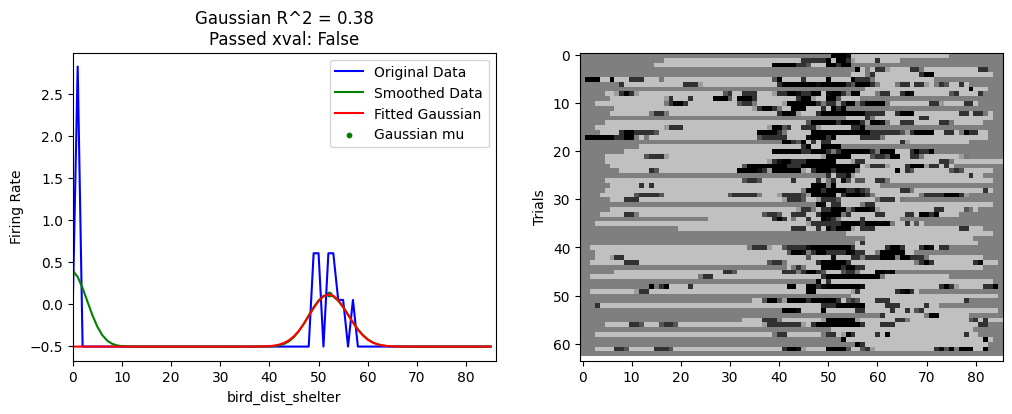

In [173]:
"""Fit gaussian using activity tuning curve pooling over all time"""

condition = 2
neuron = 13

# find the cells that have xval'd tuning curves in at least one condition
# xval_any = np.sum(xval, axis = 1) > 0
xval_any = np.ones(len(xval))
xval_id = np.where(xval_any == xval_true)[0] # we're going to use this to name the figure so that we can find neurons across conditions

test = tuning[condition][xval_any == xval_true,:]
flatline = np.where(np.diff((np.mean(test, axis = 0) == 0).astype(int)) == 1)[0]
if len(flatline) > 0:
    test = test[:,:flatline[0]]
firing_rates  = test[neuron,:]

# from scipy.ndimage import gaussian_filter1d
sigma = 3.0  # Standard deviation of the Gaussian kernel
smoothed_firing_rates = np.full_like(firing_rates, np.nan)
smoothed_firing_rates[~np.isnan(firing_rates)] = gaussian_filter1d(firing_rates[~np.isnan(firing_rates)], sigma)

# make firing rates positive
shift_constant = abs(np.amin(smoothed_firing_rates))+ 1e-6 # Add a small epsilon to avoid exact zero
smoothed_firing_rates = smoothed_firing_rates + shift_constant
distances = np.arange(len(smoothed_firing_rates))

R, y_fitted, params, double_wins = gaussian_fitting(smoothed_firing_rates, distances, verbose = False)

# Plot original data and fitted Gaussian
fig, axs = plt.subplots(1,2,figsize = (12,4))
axs[0].plot(distances, firing_rates, label="Original Data", color="blue")
axs[0].plot(distances, smoothed_firing_rates - shift_constant, label="Smoothed Data", color="green")
axs[0].plot(distances, y_fitted - shift_constant, label="Fitted Gaussian", color="red")
if double_wins:
    axs[0].scatter([params[1], params[4]],[params[0] - shift_constant, params[3] - shift_constant], label = "Gaussian mu", s = 10, color = "green")
else:
    axs[0].scatter(params[1],params[0] - shift_constant, label = "Gaussian mu", s = 10, color = "green")
axs[0].set_ylabel("Firing Rate")
axs[0].set_xlabel(comp)
axs[0].set_xlim((0, np.shape(tuning[condition])[1]))
axs[0].legend()
if double_wins:
    axs[0].set_title(f"Double Gaussian R^2 = {R:.2f}\n" 
                     f"Passed xval: {xval[neuron,condition].astype(bool)}")
else:
    axs[0].set_title(f"Gaussian R^2 = {R:.2f}\n"
                     f"Passed xval: {xval[neuron,condition].astype(bool)}")

xval_mat = mat_by_cond[condition][xval_any == xval_true,:,:]
axs[1].imshow(xval_mat[neuron,:,:], cmap="gray_r", vmin = -1, vmax = 1, aspect="auto", interpolation = "none")
# axs[1].plot(xval_mat[neuron,:,:].T)
axs[1].set_ylabel("Trials")


plt.show()

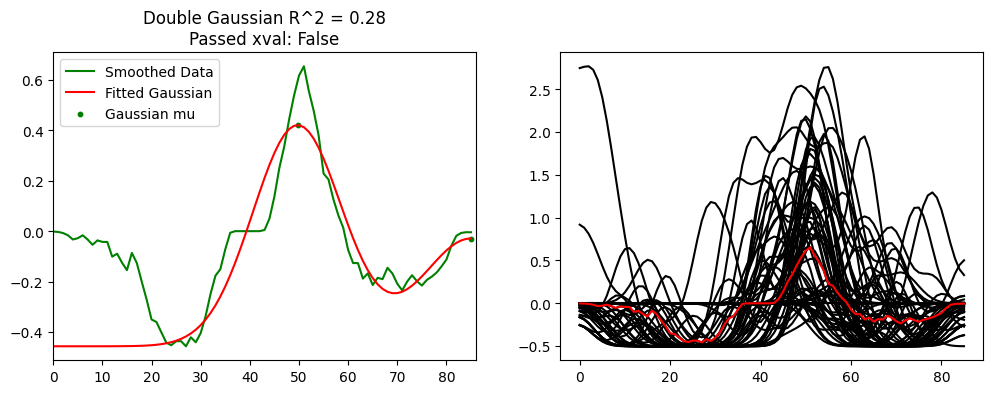

In [171]:
"""Fit gaussian using median across single trial tuning curve"""
condition = 2
neuron = 13

# find the cells that have xval'd tuning curves in at least one condition
xval_any = np.ones(len(xval))
xval_id = np.where(xval_any == xval_true)[0] # we're going to use this to name the figure so that we can find neurons across conditions

# alternative: obtain firing rates by taking median across trial
xval_mat = mat_by_cond[condition][xval_any == xval_true,:,:]
all_test = xval_mat[neuron,:,:]
all_nan_rows = np.all(np.isnan(all_test), axis=1)
all_test = all_test[~all_nan_rows,:]
all_nan_cols = np.all(np.isnan(all_test), axis=0)
all_test = all_test[:,~all_nan_cols]
firing_rates = np.nanmedian(all_test, axis=0)
smooth_test = np.zeros_like(all_test)
for sidx, sxm in enumerate(all_test):
    this_line = np.full_like(sxm, np.nan)
    where_nan = np.isnan(sxm)
    this_line[~where_nan] = gaussian_filter1d(sxm[~where_nan], 3)
    smooth_test[sidx,:] = this_line
smoothed_firing_rates = np.nanmedian(smooth_test, axis = 0)

# make firing rates positive
shift_constant = abs(np.amin(smoothed_firing_rates))+ 1e-6 # Add a small epsilon to avoid exact zero
smoothed_firing_rates = smoothed_firing_rates + shift_constant
distances = np.arange(len(smoothed_firing_rates))

R, y_fitted, params, double_wins = gaussian_fitting(smoothed_firing_rates, np.arange(len(smoothed_firing_rates)), verbose = False)

# Plot original data and fitted Gaussian
fig, axs = plt.subplots(1,2,figsize = (12,4))
axs[0].plot(distances, smoothed_firing_rates - shift_constant, label="Smoothed Data", color="green")
axs[0].plot(distances, y_fitted - shift_constant, label="Fitted Gaussian", color="red")
if double_wins:
    axs[0].scatter([params[1], params[4]],[params[0] - shift_constant, params[3] - shift_constant], label = "Gaussian mu", s = 10, color = "green")
else:
    axs[0].scatter(params[1],params[0] - shift_constant, label = "Gaussian mu", s = 10, color = "green")
axs[0].set_xlim((0, np.shape(tuning[condition])[1]))
axs[0].legend()
if double_wins:
    axs[0].set_title(f"Double Gaussian R^2 = {R:.2f}\n" 
                     f"Passed xval: {xval[neuron,condition].astype(bool)}")
else:
    axs[0].set_title(f"Gaussian R^2 = {R:.2f}\n"
                     f"Passed xval: {xval[neuron,condition].astype(bool)}")

xval_mat = mat_by_cond[condition][xval_any == xval_true,:,:]
# axs[1].imshow(smooth_test, cmap="gray_r", vmin = -1, vmax = 1.2, aspect="auto", interpolation = "none")
axs[1].plot(smooth_test.T,'k')
axs[1].plot(smoothed_firing_rates - shift_constant,'r')
plt.show()

In [269]:
"""New gaussian fitting and plotting function testing"""

method = 'across_trials'


colors = ['#228B22','#FF8C00','#008B8B']
custom_cmap = mcolors.ListedColormap(colors)
c_names = ['shelter_only', 'barrier', 'barrier_flipped']

# find the cells that have xval'd tuning curves in at least one condition
xval_any = np.ones(len(xval))
xval_id = np.where(xval_any == xval_true)[0] # we're going to use this to name the figure so that we can find neurons across conditions

# initialize variables for output
y_fitted_all = np.zeros((len(tuning), tuning[0].shape[0], tuning[0].shape[1])) # conditions x neurons x n_bins
R_all = np.zeros((len(xval_id), np.shape(xval)[1])) # neurons x conditions
param_all = np.zeros((6, len(xval_id), np.shape(xval)[1])) # params x neurons x conditions
shift_constant_all = np.zeros((len(xval_id), np.shape(xval)[1])) # neurons x conditions
double_wins_all = np.zeros((len(xval_id), np.shape(xval)[1])).astype(bool) # neurons x conditions
total_trials = np.sum([np.shape(a)[1] for a in mat_by_cond])

for neuron in np.arange(len(xval_id)):
    # initialize vars
    matrix_this_neuron = np.full((total_trials, tuning[0].shape[1]), np.nan)
    trials_by_cond = np.zeros(total_trials)
    c = 0
    # initialize plot for this neuron
    if len(mat_by_cond) > 0:
        fig = plt.figure(figsize=(12, 8))
        gs = gridspec.GridSpec(2, 3, width_ratios=[10, 10, .5], height_ratios=[1, 1])
        # Add plots
        ax1 = fig.add_subplot(gs[0, 0])  # Top-left
        ax2 = fig.add_subplot(gs[1, 0])  # Bottom left
        ax3 = fig.add_subplot(gs[:, 1])  # right column
        ax3b = fig.add_subplot(gs[:, 2])  # Spanning both rows
    else:
        fig = plt.figure(figsize=(4, 4))
        gs = gridspec.GridSpec(1, 1, figure=fig)  # 2 rows, 2 columns
        # Add plots
        ax1 = fig.add_subplot(gs[0, 0])  # Top-left

    for condition in np.arange(len(tuning)):

        if len(mat_by_cond) > 0:
            # process the firing by bin for each trial for this neuron in this 
            xval_mat = mat_by_cond[condition][xval_any == xval_true,:,:]
            all_test = xval_mat[neuron,:,:]
            # remove trials that are all nan
            all_nan_rows = np.all(np.isnan(all_test), axis=1)
            all_test = all_test[~all_nan_rows,:]
            smooth_test = np.zeros_like(all_test)
            for sidx, sxm in enumerate(all_test):
                this_line = np.full_like(sxm, np.nan)
                where_nan = np.isnan(sxm)
                this_line[~where_nan] = gaussian_filter1d(sxm[~where_nan], 3)
                smooth_test[sidx,:] = this_line

        # extract firing by bin for this neuron in this condition
        if method == 'across_trials': # only works if len(mat_by_cond) > 0:
            # alternative: obtain firing rates by taking median across trial
            all_nan_cols = np.all(np.isnan(smooth_test), axis=0)
            smoothed_firing_rates = np.full(len(all_nan_cols), np.nan)
            smoothed_firing_rates[~all_nan_cols] = np.nanmedian(smooth_test[:,~all_nan_cols], axis = 0)
        elif method == 'across_all_time':
            # obtain firing rates by taking the median in each bin for all time
            test = tuning[condition][xval_any == xval_true,:]
            flatline = np.where(np.diff((np.mean(test, axis = 0) == 0).astype(int)) == 1)[0]
            if len(flatline) > 0:
                test = test[:,:flatline[0]]
            firing_rates  = test[neuron,:]
            # from scipy.ndimage import gaussian_filter1d
            sigma = 3.0  # Standard deviation of the Gaussian kernel
            smoothed_firing_rates = np.full_like(firing_rates, np.nan)
            smoothed_firing_rates[~np.isnan(firing_rates)] = gaussian_filter1d(firing_rates[~np.isnan(firing_rates)], sigma)

        # make firing rates positive
        shift_constant = abs(np.nanmin(smoothed_firing_rates))+ 1e-6 # Add a small epsilon to avoid exact zero
        smoothed_firing_rates = smoothed_firing_rates + shift_constant
        distances = np.arange(len(smoothed_firing_rates))

        R, y, params, double_wins = gaussian_fitting(smoothed_firing_rates[~np.isnan(smoothed_firing_rates)], np.arange(np.sum(~np.isnan(smoothed_firing_rates))), verbose = False)
        y_fitted = np.full_like(smoothed_firing_rates, np.nan)
        y_fitted[~np.isnan(smoothed_firing_rates)] = y

        # dump parameters into the variables to return
        R_all[neuron, condition] = R
        shift_constant_all[neuron, condition] = shift_constant
        double_wins_all[neuron, condition] = double_wins
        param_all[:len(params),neuron, condition] = params
        y_fitted_all[condition, neuron, :len(y_fitted)] = y_fitted

        # Plot data and gaussian fit
        # top left plot: original data and gaussian fit for each condition (diff colour for each)
        ax1.plot(distances, smoothed_firing_rates - shift_constant, label="Smoothed Data " + c_names[condition], linestyle = '--', color=colors[condition])
        ax1.set_ylabel('z-scored firing rates')
        if double_wins:
            ax1.plot(distances, y_fitted - shift_constant, label=f"Double Gaussian R^2 = {R:.2f}", linestyle = '-', color=colors[condition])
        else:
            ax1.plot(distances, y_fitted - shift_constant, label=f"Gaussian R^2 = {R:.2f}", linestyle = '-', color=colors[condition])
        
        if len(mat_by_cond) > 0:
            # botom left plot: plot of activity on each trial (diff colour for each condition)
            ax2.plot(smooth_test.T, color=colors[condition], linewidth = .5, alpha = .5)
            ax2.plot(smoothed_firing_rates - shift_constant, color=colors[condition], linewidth = 2)
            ax2.set_xlabel(comp)
            ax2.set_ylabel('z-scored firing rates')
            matrix_this_neuron[c:c+smooth_test.shape[0],:] = smooth_test
            trials_by_cond[c:c+smooth_test.shape[0]] = np.ones(np.shape(smooth_test)[0])*condition
            c += smooth_test.shape[0]

    # right plot: heatmap of firing rate by bin on each trial, side bar indicating conditions
    if len(mat_by_cond) > 0:
        all_nan_rows = np.all(np.isnan(matrix_this_neuron), axis=1)
        trials_by_cond = trials_by_cond[~all_nan_rows]
        ax3.imshow(matrix_this_neuron[~all_nan_rows,:], cmap="gray_r", vmin = -1, vmax = 1, aspect="auto", interpolation = "none")
        ax3.set_ylabel("Trials")
        ax3.set_xlabel(comp)
        ax3.set_title('Median activity per trial')
        ax3b.imshow(trials_by_cond[:, np.newaxis], cmap=custom_cmap, aspect="auto")
        ax3b.set_xticks([])  # Hide x-axis ticks
        ax3b.set_yticks([])  # Hide y-axis ticks
        # Fine-tune the indicator's position to move it closer to the main heatmap
        pos_main = ax3.get_position()  # Get position of the main heatmap
        pos_indicator = ax3b.get_position()  # Get position of the indicator heatmap

        # Adjust the indicator's position
        new_x0 = pos_main.x1 + 0  # Position slightly to the right of the main heatmap
        new_x1 = new_x0 + (pos_indicator.x1 - pos_indicator.x0)  # Maintain the same width
        ax3b.set_position([new_x0, pos_indicator.y0, new_x1 - new_x0, pos_indicator.y1 - pos_indicator.y0])

        ax2.set_xlim((0, np.shape(tuning[condition])[1]))

    ax1.set_xlim((0, np.shape(tuning[condition])[1]))
    if len(mat_by_cond) == 0:
        ax1.set_xlabel(comp)
    ax1.legend(fontsize="small", markerscale=0.5)

    if xval_true:
        fig.savefig(dump_path + "/xval_neuron" + str(xval_id[neuron]) + "_allcond.png")
    else:
        fig.savefig(dump_path + "/neuron" + str(xval_id[neuron]) + "_allcond.png")
    plt.close()
